In [1]:
#import grid gdb file 
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import pyproj
from pyproj import Transformer
from shapely.geometry import Point
import matplotlib.patches as mpatches
from pathlib import Path
import numpy as np


<h1>Geopackage file import</h1>

In [2]:
centroid_gpkg_path = "/mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Selected_Selected_grids1.gpkg"
centroid_layer_name="Selected_centroids"
grid_gpkg_path="/mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Selected_Selected_grids.gpkg"
grid_layer_name="Selected_Selected_grids"
path6892513_shp="/mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/6892513/6892513.shp"
path6893080_shp="/mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/06893080/6893080.shp"
path6893390_shp="/mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/6893390/6893390.shp"

points_gdf=gpd.read_file(centroid_gpkg_path)#,layer="Selected_Selected_grids1 — selected_centroids__centroids")
grids_gdf=gpd.read_file(grid_gpkg_path,layer="selected_grids__grid")
shp6892513_gdf=gpd.read_file(path6892513_shp)
shp6893080_gdf=gpd.read_file(path6893080_shp)
shp6893390_gdf=gpd.read_file(path6893390_shp)

shp6892513_gdf=shp6892513_gdf.to_crs(epsg=26915)
shp6892513_gdf['legend_label'] = '6892513'
shp6893080_gdf=shp6893080_gdf.to_crs(epsg=26915)
shp6893080_gdf['legend_label'] = '6893080'
shp6893390_gdf=shp6893390_gdf.to_crs(epsg=26915)
shp6893390_gdf['legend_label'] = '6893390'
point_gdf_26915 = points_gdf.to_crs(epsg=26915)




<h1>Station importer</h1>

In [3]:
lat_lon_path="/mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/raingage_lat_lon.csv"
coordinate_df=pd.read_csv(lat_lon_path)

transformer = Transformer.from_crs("EPSG:4326", "EPSG:26915",always_xy=True)

long,lat=transformer.transform(coordinate_df["Longitude"].to_numpy(), 
                               coordinate_df["Latitude"].to_numpy())
coordinate_df["NAD83_15N_Lat"]=lat
coordinate_df["NAD83_15N_Long"]=long

geometry = [
    Point(xy) for xy in zip(
        coordinate_df["NAD83_15N_Long"],  
        coordinate_df["NAD83_15N_Lat"]     
    )
]

station_gdf = gpd.GeoDataFrame(
    coordinate_df,
    geometry=geometry,
    crs="EPSG:26915"   # NAD83 UTM 15N
)

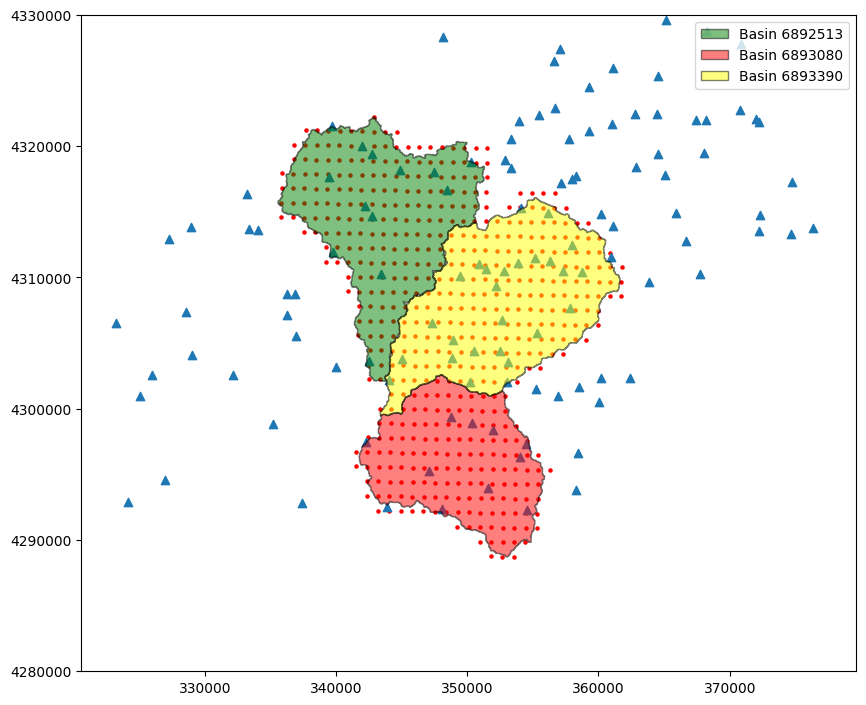

In [4]:
fig, ax = plt.subplots(figsize=(10, 10))
point_gdf_26915.plot(ax=ax, color='red', markersize=5)
station_gdf.plot(ax=ax, marker="^",label="Rain gage") 
shp6892513_gdf.plot( legend=True,ax=ax,alpha=0.5, color='green', edgecolor='black')
shp6893080_gdf.plot( legend=True,ax=ax,alpha=0.5, color='red', edgecolor='black')
shp6893390_gdf.plot( legend=True,ax=ax,alpha=0.5, color='yellow', edgecolor='black')
ax.set_ylim(4280000,4330000)

legend_handles = [
    mpatches.Patch(facecolor='green', alpha=0.5, edgecolor='black', label='Basin 6892513'),
    mpatches.Patch(facecolor='red', alpha=0.5, edgecolor='black', label='Basin 6893080'),
    mpatches.Patch(facecolor='yellow', alpha=0.5, edgecolor='black', label='Basin 6893390')
]

ax.legend(handles=legend_handles, loc='upper right', frameon=True)
ax.ticklabel_format(style='plain', useOffset=False, axis='both')

<h1>Create GDF of centroids for each catchment area</h1>

In [7]:
grids_26915  = grids_gdf.to_crs(epsg=26915).copy()
points_26915 = points_gdf.to_crs(epsg=26915).copy()

OUT_DIR = Path("/mnt/12TB/Sujan/Spatial_correlation/Codes/Buffer_information")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def select_grids_and_centroids_for_catchment(
    catchment_gdf: gpd.GeoDataFrame,
    catchment_name: str,
    grids: gpd.GeoDataFrame,
    centroids: gpd.GeoDataFrame,
    out_dir: Path
):
    # dissolve catchment to one geometry (handles multipart / multiple features)
    catch_union = catchment_gdf.geometry.unary_union

    # 1) grids that intersect catchment
    grids_sel = grids[grids.intersects(catch_union)].copy()

    # 2) centroids that fall within the selected grids
    # Use spatial join for correctness + speed
    # (predicate="within": point within polygon)
    cent_sel = gpd.sjoin(
        centroids,
        grids_sel[["geometry"]].copy(),
        how="inner",
        predicate="within"
    ).drop(columns=["index_right"], errors="ignore")

    # optional: keep only unique points if duplicates occur
    cent_sel = cent_sel.drop_duplicates(subset=["geometry"])

    # Write outputs (one gpkg per catchment, two layers inside)
    out_gpkg = out_dir / f"{catchment_name}_grids_centroids.gpkg"
    grids_sel.to_file(out_gpkg, layer="selected_grids", driver="GPKG")
    cent_sel.to_file(out_gpkg, layer="selected_centroids", driver="GPKG")

    print(f"[OK] {catchment_name}: grids={len(grids_sel)}, centroids={len(cent_sel)} -> {out_gpkg}")

    return grids_sel, cent_sel

# Run for each catchment
grids_6892513, cent_6892513 = select_grids_and_centroids_for_catchment(
    shp6892513_gdf, "6892513", grids_26915, points_26915, OUT_DIR
)

grids_6893080, cent_6893080 = select_grids_and_centroids_for_catchment(
    shp6893080_gdf, "6893080", grids_26915, points_26915, OUT_DIR
)

grids_6893390, cent_6893390 = select_grids_and_centroids_for_catchment(
    shp6893390_gdf, "6893390", grids_26915, points_26915, OUT_DIR
)

/tmp/ipykernel_2202698/3748913402.py:15: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  catch_union = catchment_gdf.geometry.unary_union
/tmp/ipykernel_2202698/3748913402.py:15: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  catch_union = catchment_gdf.geometry.unary_union


[OK] 6892513: grids=195, centroids=195 -> /mnt/12TB/Sujan/Spatial_correlation/Codes/Buffer_information/6892513_grids_centroids.gpkg
[OK] 6893080: grids=154, centroids=154 -> /mnt/12TB/Sujan/Spatial_correlation/Codes/Buffer_information/6893080_grids_centroids.gpkg
[OK] 6893390: grids=215, centroids=215 -> /mnt/12TB/Sujan/Spatial_correlation/Codes/Buffer_information/6893390_grids_centroids.gpkg


/tmp/ipykernel_2202698/3748913402.py:15: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  catch_union = catchment_gdf.geometry.unary_union


<h1>Create buffer database</h1>

In [12]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

# --- inputs you already have ---
# stations  = station_gdf.to_crs(epsg=26915).copy()
# centroids for each catchment: cent_6892513, cent_6893080, cent_6893390  (from earlier step)

OUT_DIR = Path("/mnt/12TB/Sujan/Spatial_correlation/Codes/Buffer_information")
OUT_DIR.mkdir(parents=True, exist_ok=True)

buffer_km_list = [3, 4, 5, 6, 7, 8]
CENTROID_ID_COL = "ID"   # change if needed (e.g., "fid")

def count_stations_within_radius(
    centroids_gdf: gpd.GeoDataFrame,
    stations_gdf: gpd.GeoDataFrame,
    radius_m: float,
    centroid_id_col: str = "ID",
) -> pd.DataFrame:
    """
    For each centroid, count stations within a buffer radius.
    Returns a table with centroid coords + count.
    """
    centroids_gdf = centroids_gdf.to_crs(epsg=26915).copy()
    stations_gdf  = stations_gdf.to_crs(epsg=26915).copy()

    stations_sindex = stations_gdf.sindex

    rows = []
    for idx, crow in centroids_gdf.iterrows():
        cgeom = crow.geometry
        buf = cgeom.buffer(radius_m)

        # bbox candidates
        cand_idx = list(stations_sindex.intersection(buf.bounds))
        cand = stations_gdf.iloc[cand_idx]

        # exact within
        n_in = int(cand.within(buf).sum())

        cid = crow[centroid_id_col] if (centroid_id_col in centroids_gdf.columns) else idx

        rows.append({
            "centroid_id": cid,
            "centroid_x": cgeom.x,
            "centroid_y": cgeom.y,
            "buffer_m": radius_m,
            "buffer_km": radius_m / 1000.0,
            "n_stations": n_in,
        })

    return pd.DataFrame(rows)

def run_buffers_for_catchment(
    catchment_name: str,
    catchment_centroids: gpd.GeoDataFrame,
    stations_gdf: gpd.GeoDataFrame,
    buffer_km_list: list[int],
    out_dir: Path,
    centroid_id_col: str = "ID",
):
    """
    Writes one CSV per buffer distance for the given catchment.
    """
    for km in buffer_km_list:
        radius_m = km * 1000.0
        df_out = count_stations_within_radius(
            catchment_centroids,
            stations_gdf,
            radius_m,
            centroid_id_col=centroid_id_col,
        )

        out_csv = out_dir / f"{catchment_name}_stations_within_{km:02d}km.csv"
        df_out.to_csv(out_csv, index=False)
        print(f"[OK] {catchment_name}: wrote {out_csv} (rows={len(df_out)})")

# -------------------------
# Run for each catchment
# -------------------------
# (use the centroid GDFs you created earlier)
run_buffers_for_catchment("6892513", cent_6892513, stations, buffer_km_list, OUT_DIR, centroid_id_col=CENTROID_ID_COL)
run_buffers_for_catchment("6893080", cent_6893080, stations, buffer_km_list, OUT_DIR, centroid_id_col=CENTROID_ID_COL)
run_buffers_for_catchment("6893390", cent_6893390, stations, buffer_km_list, OUT_DIR, centroid_id_col=CENTROID_ID_COL)

[OK] 6892513: wrote /mnt/12TB/Sujan/Spatial_correlation/Codes/Buffer_information/6892513_stations_within_03km.csv (rows=195)
[OK] 6892513: wrote /mnt/12TB/Sujan/Spatial_correlation/Codes/Buffer_information/6892513_stations_within_04km.csv (rows=195)
[OK] 6892513: wrote /mnt/12TB/Sujan/Spatial_correlation/Codes/Buffer_information/6892513_stations_within_05km.csv (rows=195)
[OK] 6892513: wrote /mnt/12TB/Sujan/Spatial_correlation/Codes/Buffer_information/6892513_stations_within_06km.csv (rows=195)
[OK] 6892513: wrote /mnt/12TB/Sujan/Spatial_correlation/Codes/Buffer_information/6892513_stations_within_07km.csv (rows=195)
[OK] 6892513: wrote /mnt/12TB/Sujan/Spatial_correlation/Codes/Buffer_information/6892513_stations_within_08km.csv (rows=195)
[OK] 6893080: wrote /mnt/12TB/Sujan/Spatial_correlation/Codes/Buffer_information/6893080_stations_within_03km.csv (rows=154)
[OK] 6893080: wrote /mnt/12TB/Sujan/Spatial_correlation/Codes/Buffer_information/6893080_stations_within_04km.csv (rows=154)


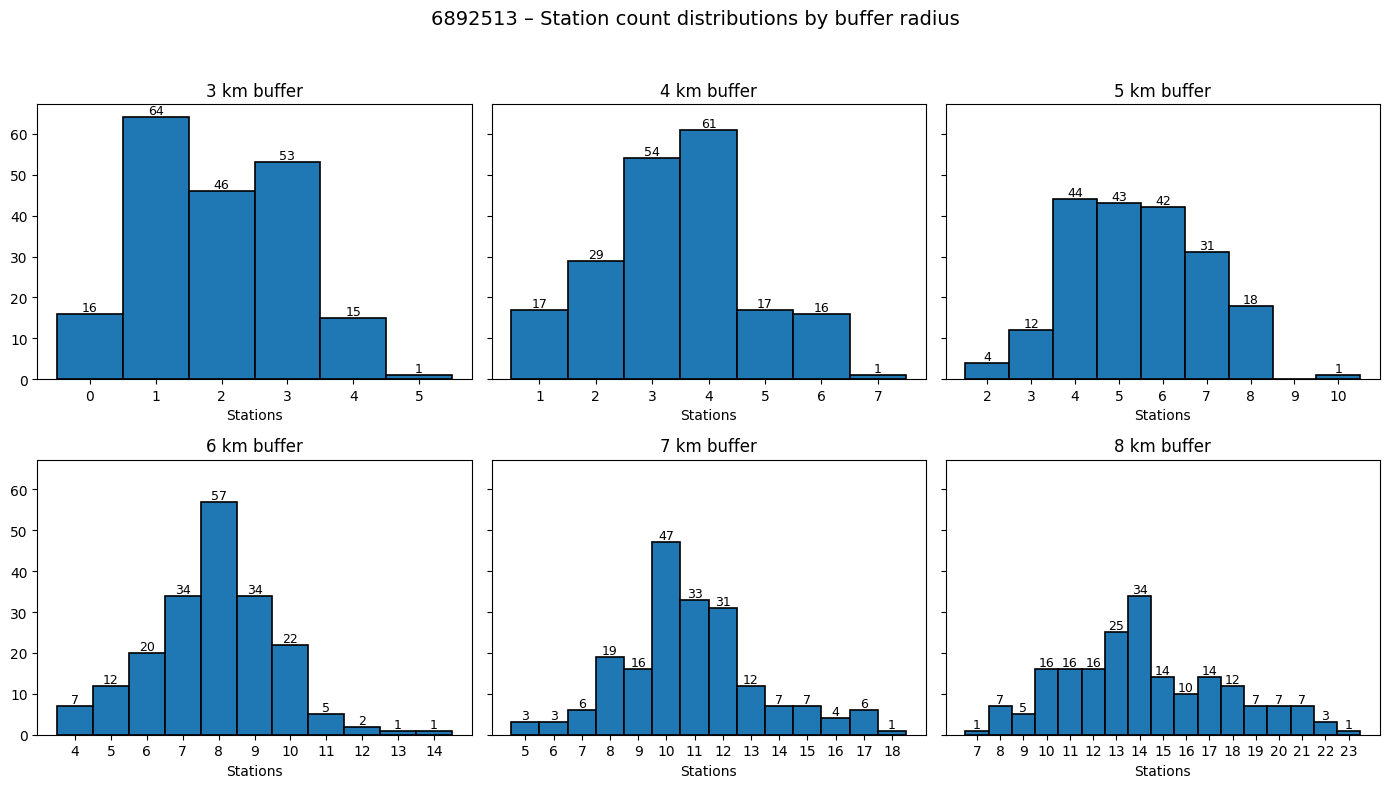

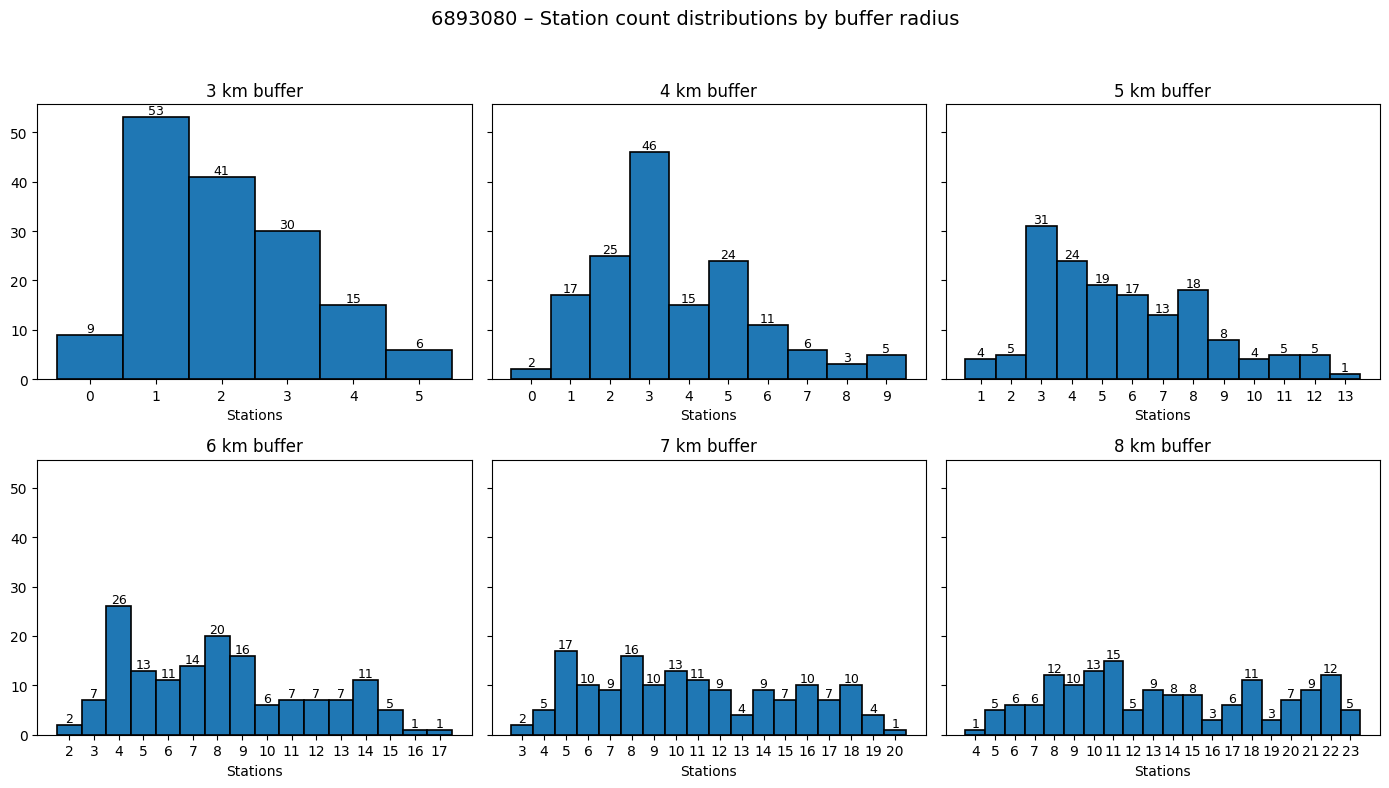

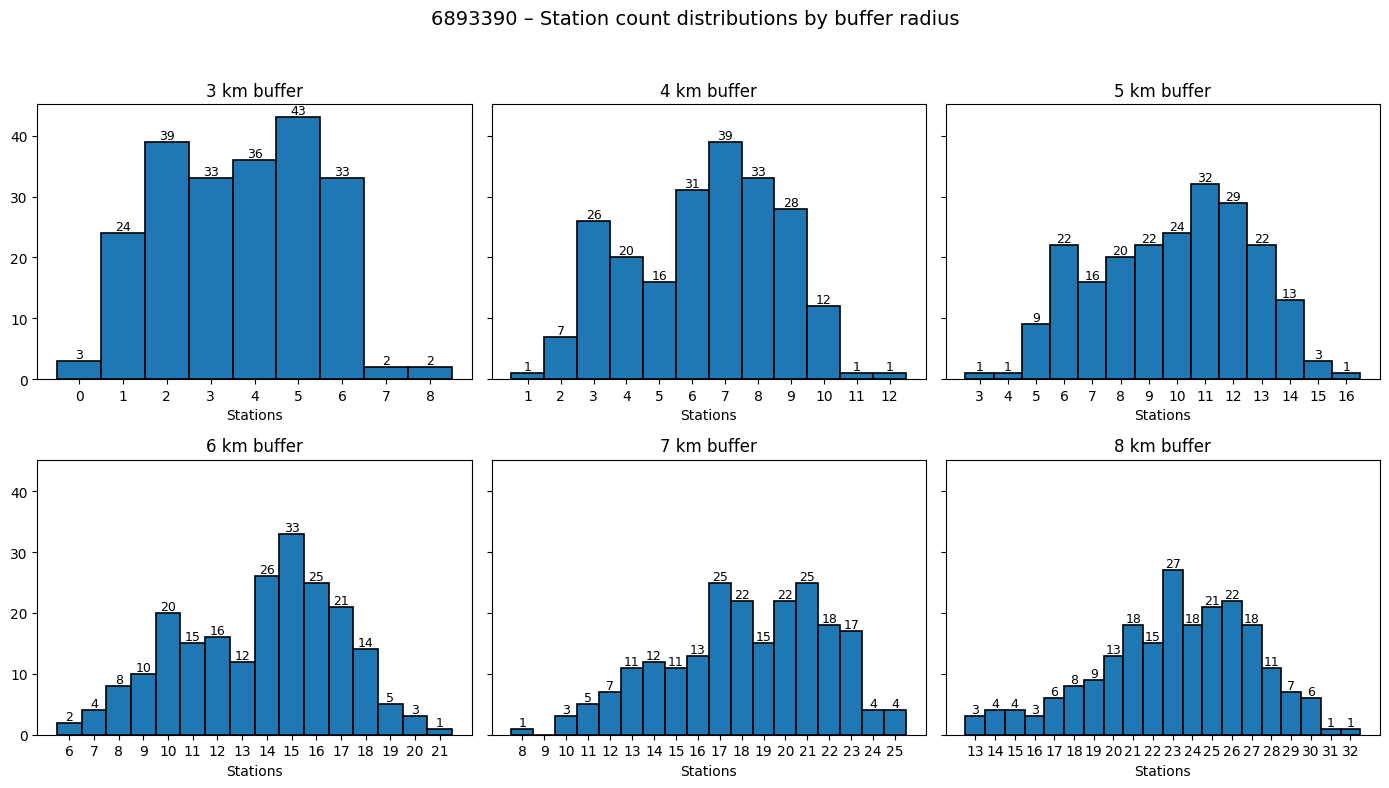

In [14]:
def plot_combined_histograms(catchment_name, out_dir, buffer_km_list):
    
    n_buffers = len(buffer_km_list)
    ncols = 3
    nrows = int(np.ceil(n_buffers / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 8), sharey=True)
    axes = axes.flatten()

    for ax_idx, km in enumerate(buffer_km_list):
        ax = axes[ax_idx]
        csv_path = out_dir / f"{catchment_name}_stations_within_{km:02d}km.csv"

        if not csv_path.exists():
            ax.set_title(f"{km} km (missing)")
            ax.axis("off")
            continue

        df = pd.read_csv(csv_path)
        counts = df["n_stations"].dropna().astype(int).values

        if counts.size == 0:
            ax.set_title(f"{km} km (no data)")
            ax.axis("off")
            continue

        bins = np.arange(counts.min() - 0.5,
                         counts.max() + 1.5,
                         1)

        n, bin_edges, patches = ax.hist(
            counts,
            bins=bins,
            edgecolor="black",
            linewidth=1.2
        )

        ax.set_title(f"{km} km buffer")
        ax.set_xlabel("Stations")
        ax.set_xticks(np.arange(int(counts.min()), int(counts.max()) + 1, 1))

        # Add bar counts
        for i, p in enumerate(patches):
            height = n[i]
            if height > 0:
                x = p.get_x() + p.get_width() / 2
                ax.text(x, height, f"{int(height)}",
                        ha="center", va="bottom", fontsize=9)

    # Hide unused subplots if any
    for j in range(len(buffer_km_list), len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"{catchment_name} – Station count distributions by buffer radius", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# Run for each catchment
plot_combined_histograms("6892513", OUT_DIR, buffer_km_list)
plot_combined_histograms("6893080", OUT_DIR, buffer_km_list)
plot_combined_histograms("6893390", OUT_DIR, buffer_km_list)

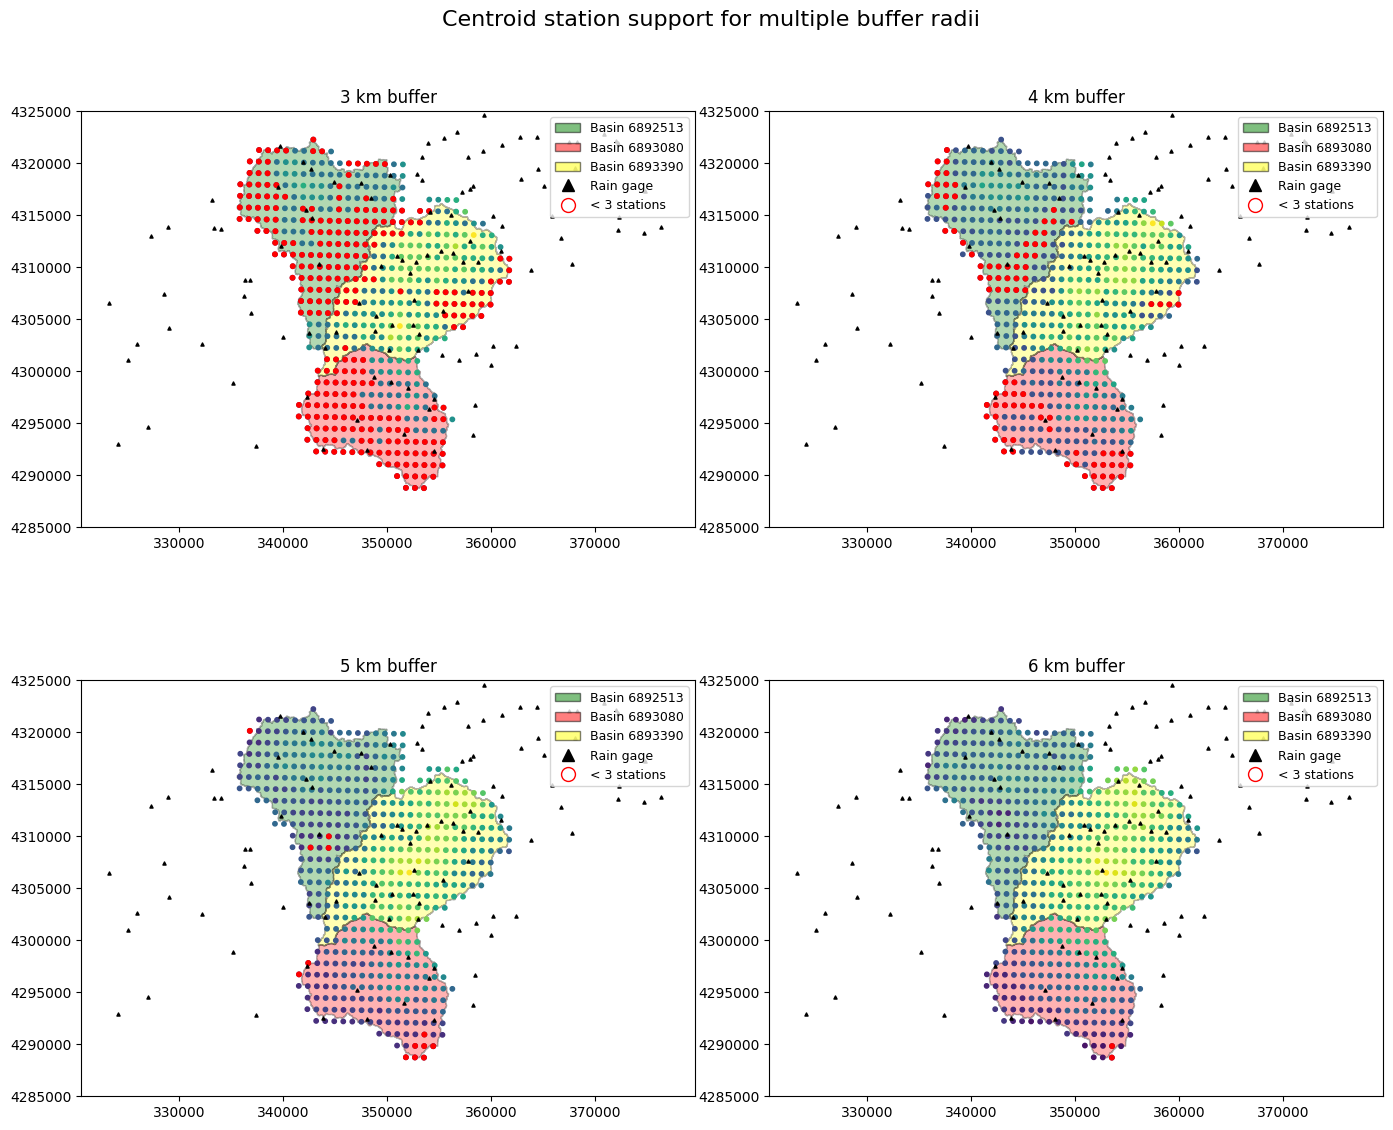

In [40]:
def plot_centroid_station_support_multi_radius(
    centroids_gdf,              # e.g., point_gdf_26915  (or catchment-specific centroids)
    stations_gdf,               # station_gdf in EPSG:26915
    basins_gdfs,                # list of (gdf, facecolor, label)
    radii_km=(3, 4, 5, 6),
    centroid_id_col="ID",
    bad_thresh=3,
    ylim=(4280000, 4330000),
):
    """
    Creates ONE figure with subplots (2x2) for multiple radii.
    Each subplot colors centroids by #stations within radius,
    and outlines centroids with < bad_thresh in red.
    """
    radii_km = list(radii_km)
    n = len(radii_km)
    ncols = 2
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 12))
    axes = axes.flatten()

    # Basin legend patches (same for all panels)
    basin_patches = [mpatches.Patch(facecolor=c, alpha=0.5, edgecolor="black", label=lab)
                     for (_, c, lab) in basins_gdfs]

    for ax, km in zip(axes, radii_km):
        radius_m = km * 1000.0

        # Compute counts
        df_out = count_stations_within_radius(
            centroids_gdf=centroids_gdf,
            stations_gdf=stations_gdf,
            radius_m=radius_m,
            centroid_id_col=centroid_id_col,
        )

        cent_count_gdf = gpd.GeoDataFrame(
            df_out,
            geometry=gpd.points_from_xy(df_out["centroid_x"], df_out["centroid_y"]),
            crs="EPSG:26915",
        )
                # Plot basins
        for basin_gdf, facecolor, _lab in basins_gdfs:
            basin_gdf.plot(ax=ax, alpha=0.3, color=facecolor, edgecolor="black")

        # Plot centroids colored by station count
        cent_count_gdf.plot(
            ax=ax,
            column="n_stations",
            markersize=10
        )

        # Highlight "bad" centroids (< bad_thresh)
        bad = cent_count_gdf[cent_count_gdf["n_stations"] < bad_thresh]
        if not bad.empty:
            bad.plot(ax=ax, facecolor="none", edgecolor="red", markersize=5, linewidth=2)
            
        # Cosmetics
        ax.set_title(f"{km} km buffer")
        ax.set_ylim(*ylim)
        ax.ticklabel_format(style="plain", useOffset=False, axis="both")
        
        # Plot stations
        stations_gdf.plot(ax=ax, marker="^", markersize=5, color="black")

        
        # Add basin legend + bad marker (only once per subplot for clarity)
        extra_handles = basin_patches + [
            plt.Line2D([0], [0], marker="^", color="black", linestyle="None", markersize=8, label="Rain gage"),
            plt.Line2D([0], [0], marker="o", color="red", linestyle="None",
                       markerfacecolor="none", markersize=10, label=f"< {bad_thresh} stations"),
        ]
        ax.legend(handles=extra_handles, loc="upper right", frameon=True, fontsize=9)
        
    # Turn off any unused axes (if radii_km not multiple of 2)
    for j in range(len(radii_km), len(axes)):
        axes[j].axis("off")

    fig.suptitle("Centroid station support for multiple buffer radii", fontsize=16)

    fig.subplots_adjust(
        left=0.05,
        right=0.98,
        top=0.92,
        bottom=0.05,
        wspace=0.12
    )

    plt.show()


# -------------------------
# CALL IT (using your objects)
# -------------------------
basins_gdfs = [
    (shp6892513_gdf, "green",  "Basin 6892513"),
    (shp6893080_gdf, "red",    "Basin 6893080"),
    (shp6893390_gdf, "yellow", "Basin 6893390"),
]

plot_centroid_station_support_multi_radius(
    centroids_gdf=point_gdf_26915,
    stations_gdf=station_gdf.to_crs(epsg=26915),
    basins_gdfs=basins_gdfs,
    radii_km=(3, 4, 5, 6),
    centroid_id_col="ID",
    bad_thresh=3,
    ylim=(4285000, 4325000),
)